In [1]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models
from torchvision.datasets import ImageFolder

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    auc,
    precision_recall_curve
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class CTDataset(Dataset):
    def __init__(self, image_paths, labels, image_size=256, augment=False, use_clahe=False):
        self.image_paths = image_paths
        self.labels = labels
        self.image_size = image_size
        self.augment = augment
        self.use_clahe = use_clahe

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        self.clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

    def __len__(self):
        return len(self.image_paths)

    def apply_clahe(self, img):
        img_u8 = (img * 255.0).clip(0, 255).astype(np.uint8)
        img_u8 = self.clahe.apply(img_u8)
        return img_u8.astype(np.float32) / 255.0

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]

        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")

        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        img = cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_AREA
        )

        img = img.astype(np.float32)

        if img.max() > 255:
            img = img / 65535.0
        else:
            img = img / 255.0

        if self.use_clahe:
            img = self.apply_clahe(img)

        if self.augment:
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()

            if np.random.rand() < 0.5:
                angle = np.random.uniform(-10, 10)
                M = cv2.getRotationMatrix2D(
                    (self.image_size // 2, self.image_size // 2),
                    angle,
                    1.0
                )
                img = cv2.warpAffine(
                    img,
                    M,
                    (self.image_size, self.image_size),
                    borderMode=cv2.BORDER_REFLECT
                )

            if np.random.rand() < 0.5:
                alpha = np.random.uniform(0.9, 1.1)
                beta = np.random.uniform(-0.05, 0.05)
                img = np.clip(alpha * img + beta, 0, 1)

            if np.random.rand() < 0.3:
                noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
                img = np.clip(img + noise, 0, 1)

        img = torch.from_numpy(img.astype(np.float32)).unsqueeze(0)
        img = img.repeat(3, 1, 1)

        img = (img - self.mean) / self.std

        label = torch.tensor(label, dtype=torch.long)

        return img, label

In [4]:
train_dir = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\train"
val_dir   = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\val"
test_dir  = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\test"

img_size = 256
batch_size = 16
num_workers = 0
dropout_rate = 0.6

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

In [5]:
train_base = ImageFolder(train_dir)
val_base = ImageFolder(val_dir)
test_base = ImageFolder(test_dir)

train_paths = [s[0] for s in train_base.samples]
train_labels = [s[1] for s in train_base.samples]

val_paths = [s[0] for s in val_base.samples]
val_labels = [s[1] for s in val_base.samples]

test_paths = [s[0] for s in test_base.samples]
test_labels = [s[1] for s in test_base.samples]

class_names = train_base.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Classes: ['no_nodule', 'nodule']
Train: 4050
Val: 860
Test: 890


In [6]:
train_data = CTDataset(train_paths, train_labels, image_size=img_size)
val_data = CTDataset(val_paths, val_labels, image_size=img_size)
test_data = CTDataset(test_paths, test_labels, image_size=img_size)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [7]:
model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(model.fc.in_features, num_classes)
)

model_path = "saved_models/resnet50_best_sen.pth"
model.load_state_dict(torch.load(model_path, map_location=device))

model = model.to(device)
model.eval()

print("Loaded trained ResNet50")

Loaded trained ResNet50


C:\Users\rgzep\AppData\Local\Temp\ipykernel_4748\138061949.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=devi

In [8]:
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [9]:
def extract_features(dataloader, feature_extractor, device):
    all_features = []
    all_labels = []

    feature_extractor.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            features = feature_extractor(images)
            features = features.view(features.size(0), -1)

            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    return X, y

In [10]:
X_train, y_train = extract_features(train_loader, feature_extractor, device)
X_val, y_val = extract_features(val_loader, feature_extractor, device)
X_test, y_test = extract_features(test_loader, feature_extractor, device)

print("Train features:", X_train.shape)
print("Val features:", X_val.shape)
print("Test features:", X_test.shape)

Train features: (4050, 2048)
Val features: (860, 2048)
Test features: (890, 2048)


In [11]:
X_train_full = np.concatenate([X_train, X_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

print("Combined train+val features:", X_train_full.shape)

Combined train+val features: (4910, 2048)


In [12]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("svm", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

In [13]:
param_grid = {
    "pca__n_components": [100],
    "svm__kernel": ["rbf"],   # remove linear
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale"]
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    scoring="recall_macro",
    cv=3,
    n_jobs=2,
    verbose=3
)

grid_search.fit(X_train_full, y_train_full)

svm_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)
print("Best CV macro recall:", grid_search.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters:
{'pca__n_components': 100, 'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV macro recall: 0.7942567420322931


In [14]:
val_pred = svm_model.predict(X_val)
val_prob = svm_model.predict_proba(X_val)[:, 1]

val_acc = accuracy_score(y_val, val_pred)
val_auc = roc_auc_score(y_val, val_prob)
val_rec = recall_score(y_val, val_pred, average="macro")

print("Validation Accuracy:", round(val_acc, 4))
print("Validation AUC:", round(val_auc, 4))
print("Validation Recall:", round(val_rec, 4))


print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_pred))

print("\nClassification Report:")
print(classification_report(
    y_val,
    val_pred,
    target_names=class_names
))

Validation Accuracy: 0.7965
Validation AUC: 0.9259
Validation Recall: 0.8307

Confusion Matrix:
[[208  22]
 [153 477]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.58      0.90      0.70       230
      nodule       0.96      0.76      0.84       630

    accuracy                           0.80       860
   macro avg       0.77      0.83      0.77       860
weighted avg       0.85      0.80      0.81       860



In [15]:
test_pred = svm_model.predict(X_test)
test_prob = svm_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)
test_rec = recall_score(y_test, test_pred,  average="macro")

print("Test Accuracy:", round(test_acc, 4))
print("Test AUC:", round(test_auc, 4))
print("Test Recall:", round(test_rec, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    test_pred,
    target_names=class_names
))

Test Accuracy: 0.7416
Test AUC: 0.819
Test Recall: 0.7448

Confusion Matrix:
[[188  62]
 [168 472]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.53      0.75      0.62       250
      nodule       0.88      0.74      0.80       640

    accuracy                           0.74       890
   macro avg       0.71      0.74      0.71       890
weighted avg       0.78      0.74      0.75       890



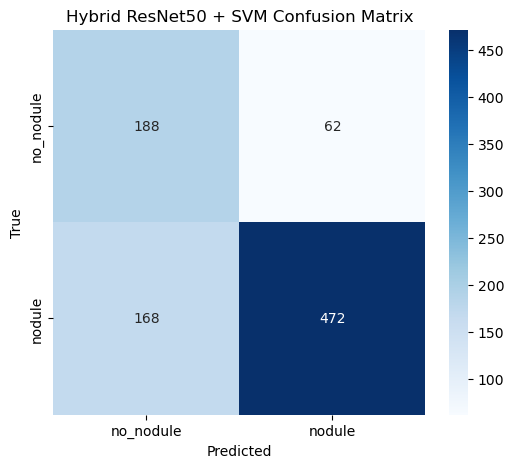

In [16]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hybrid ResNet50 + SVM Confusion Matrix")
plt.show()

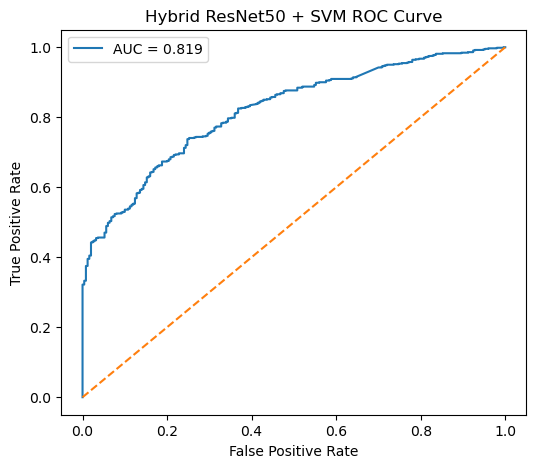

In [17]:
fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Hybrid ResNet50 + SVM ROC Curve")
plt.legend()
plt.show()

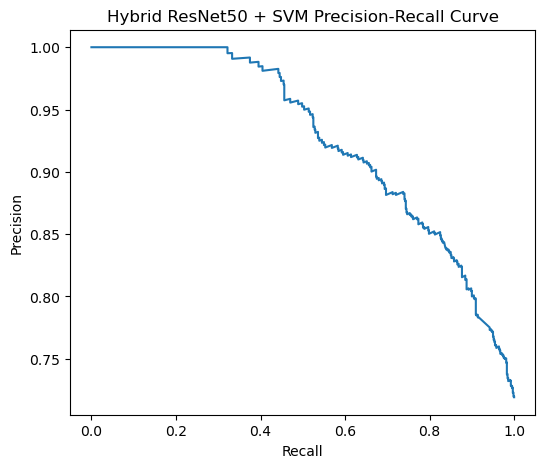

In [18]:
precision, recall, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Hybrid ResNet50 + SVM Precision-Recall Curve")
plt.show()

In [19]:
joblib.dump(
    svm_model,
    "saved_models/resnet50_svm_tuned.pkl"
)

print("Saved tuned SVM model.")

Saved tuned SVM model.
